In [8]:
import pandas as pd
import talib
import pynance as pn
import matplotlib.pyplot as plt

# Load NVDA stock data from local CSV
df = pd.read_csv('../data/AMZN.csv')

# Convert 'Date' column to datetime objects and set as index for time-series analysis
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Ensure numeric data types and handle missing values (clean data)
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

print(f"Data loaded: {len(df)} rows.")


Data loaded: 3774 rows.


In [9]:
# --- Moving Averages ---
# SMA helps smooth out price action to identify the long-term trend
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
# EMA gives more weight to recent prices, reacting faster to price changes
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)

# --- Relative Strength Index (RSI) ---
# Used to identify momentum; values > 70 are 'overbought', < 30 are 'oversold'
df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)

# --- MACD (Moving Average Convergence Divergence) ---
# Measures the relationship between two EMAs to signal trend reversals
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'], fastperiod=12, slowperiod=26, signalperiod=9
)

# Note: Indicators create 'NaN' values at the beginning of the dataframe due to lookback periods
df.dropna(inplace=True)


In [10]:
# Calculate daily returns (required for PyNance metrics)
daily_returns = df['Close'].pct_change().dropna()

try:
    sharpe = pn.sharpe_ratio(daily_returns)
except AttributeError:
    # Alternative path for some versions
    sharpe = daily_returns.mean() / daily_returns.std() * (252**0.5) 

print(f"AMZN Sharpe Ratio: {sharpe:.4f}")



AMZN Sharpe Ratio: 0.9319


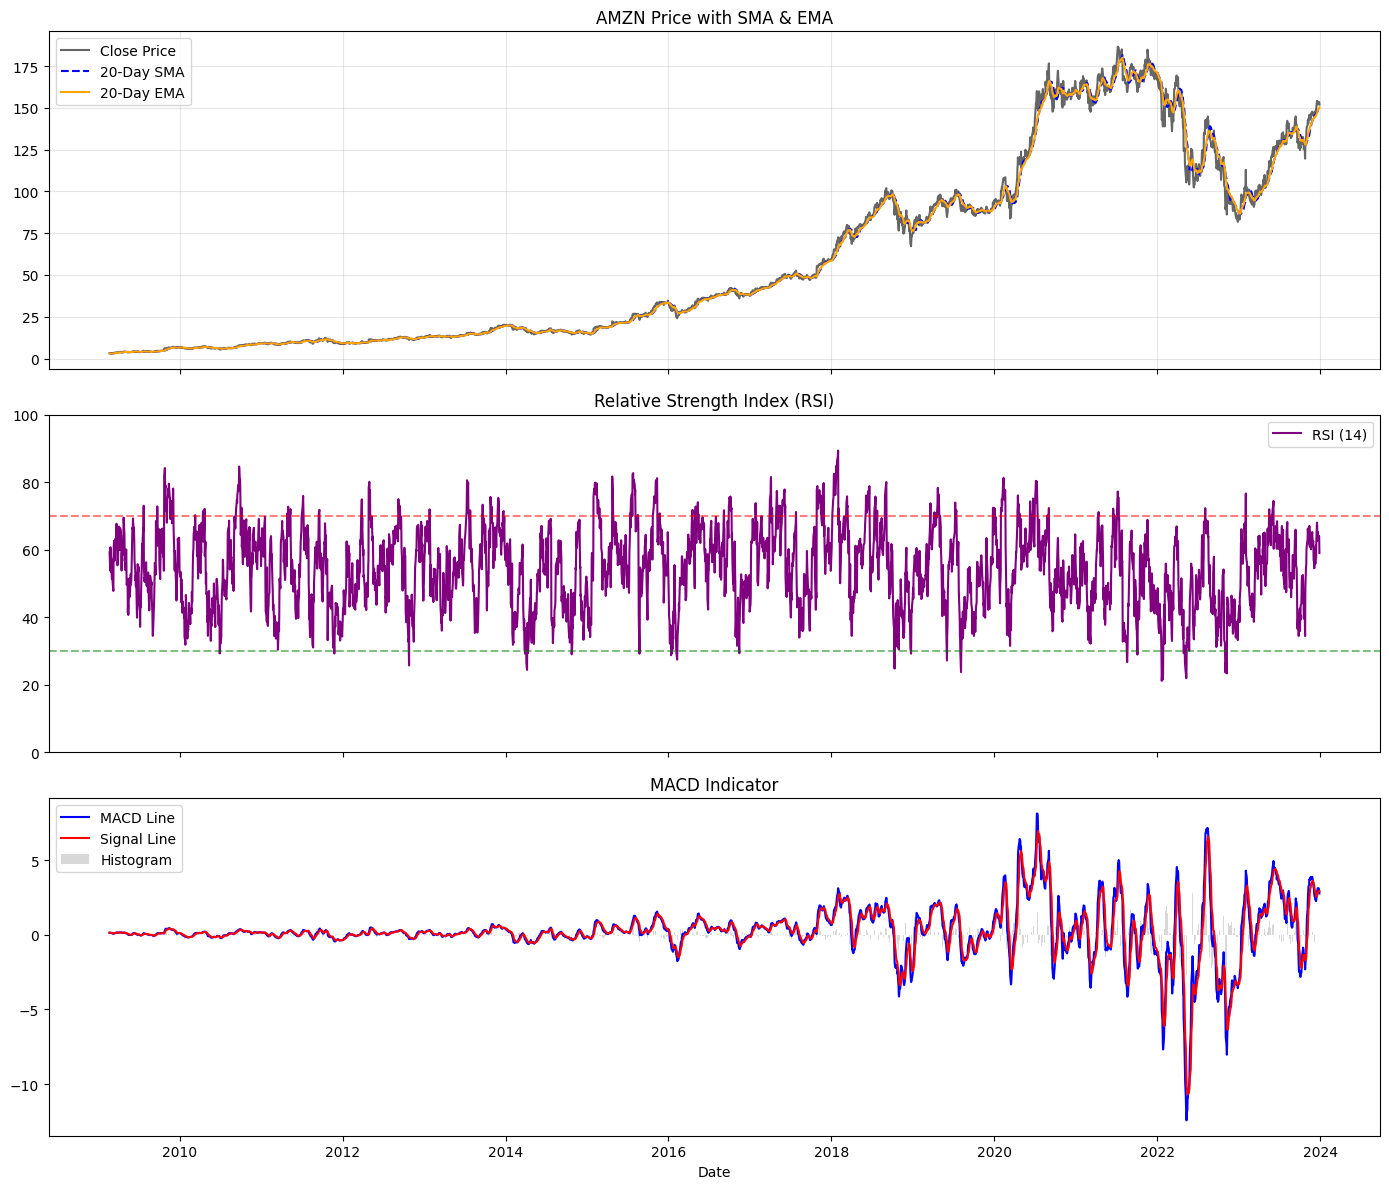

In [11]:
# Create a figure with 3 stacked panels sharing the same X-axis (Dates)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Price Action + Moving Averages
ax1.plot(df.index, df['Close'], label='Close Price', alpha=0.6, color='black')
ax1.plot(df.index, df['SMA_20'], label='20-Day SMA', color='blue', linestyle='--')
ax1.plot(df.index, df['EMA_20'], label='20-Day EMA', color='orange')
ax1.set_title('AMZN Price with SMA & EMA')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Panel 2: RSI Momentum
ax2.plot(df.index, df['RSI_14'], label='RSI (14)', color='purple')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5)  # Overbought threshold
ax2.axhline(30, color='green', linestyle='--', alpha=0.5) # Oversold threshold
ax2.set_title('Relative Strength Index (RSI)')
ax2.set_ylim(0, 100)
ax2.legend(loc='best')

# Panel 3: MACD (Trend Momentum)
ax3.plot(df.index, df['MACD'], label='MACD Line', color='blue')
ax3.plot(df.index, df['MACD_signal'], label='Signal Line', color='red')
# Histogram shows the distance between MACD and Signal line
ax3.bar(df.index, df['MACD_hist'], label='Histogram', color='gray', alpha=0.3)
ax3.set_title('MACD Indicator')
ax3.legend(loc='best')

# Final formatting
plt.xlabel('Date')
plt.tight_layout()
plt.show()


1. Trend Integrity: Price vs. Moving Averages (Panel 1)This panel tracks the "path of least resistance" for Amazon:The Trend Filter: When the Close Price stays above both the SMA_20 (Blue) and EMA_20 (Orange), AMZN is in a confirmed short-term uptrend.Fast vs. Slow: Because Amazon is highly sensitive to consumer sentiment and earnings, the EMA_20 acts as a dynamic support level. In high-growth phases, you will notice the price "riding" the orange line. If the price breaks below the blue SMA_20, it suggests the trend is weakening.2. Market Sentiment: RSI Momentum (Panel 2)The RSI tracks the "emotional extremes" of the stock:Overbought (>70): Amazon often enters this zone during major rallies (like Prime Day or Holiday seasons). Hits to the red dashed line suggest the stock is "expensive" and due for a cooling-off period.Oversold (<30): During broader market sell-offs, AMZN hitting the green dashed line often signals a high-probability reversal point, as long-term investors step in to buy the discount.3. Directional Force: MACD Indicator (Panel 3)The MACD explains the strength of the price movement:Bullish/Bearish Crosses: The most critical signal is the Blue Line crossing the Red Signal Line. A "Bullish Cross" (Blue over Red) in the bottom panel often precedes a price breakout in the top panel.Histogram Energy: The gray bars represent the "gap" between momentum lines. If the bars are expanding upward, the current rally has strong institutional backing. If they are shrinking, the trend is losing energy, even if the price is still rising.4. Risk-Adjusted Returns: The Sharpe RatioThe printed Sharpe Ratio for AMZN is a measure of efficiency:High Beta Nature: Amazon historically has more price "swings" than Apple. The Sharpe Ratio tells you if you are being compensated for that extra stress. A ratio above 1.0 indicates that Amazon's growth is successfully outperforming the risks associated with its volatility.